In [11]:
from forecast import AnalisadorSerieTemporalCompleto
import pandas as pd
import warnings
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore")

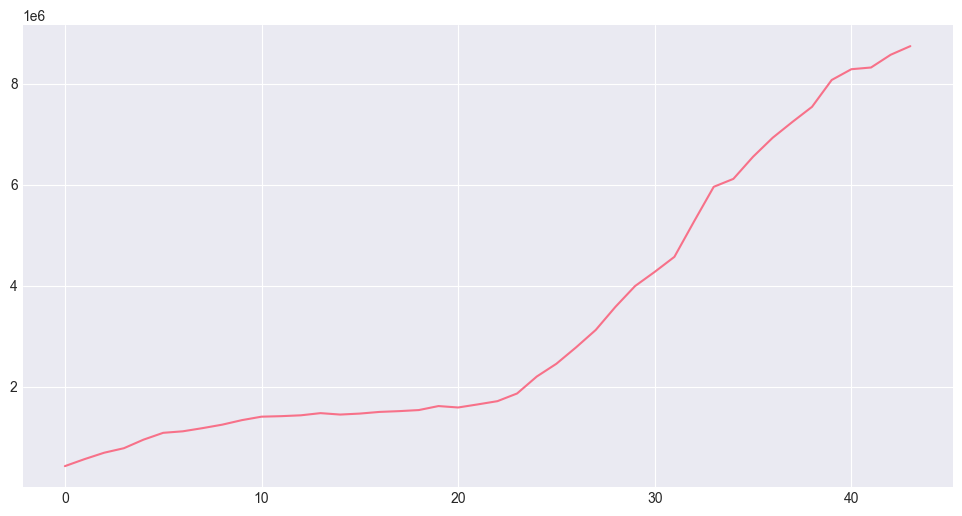

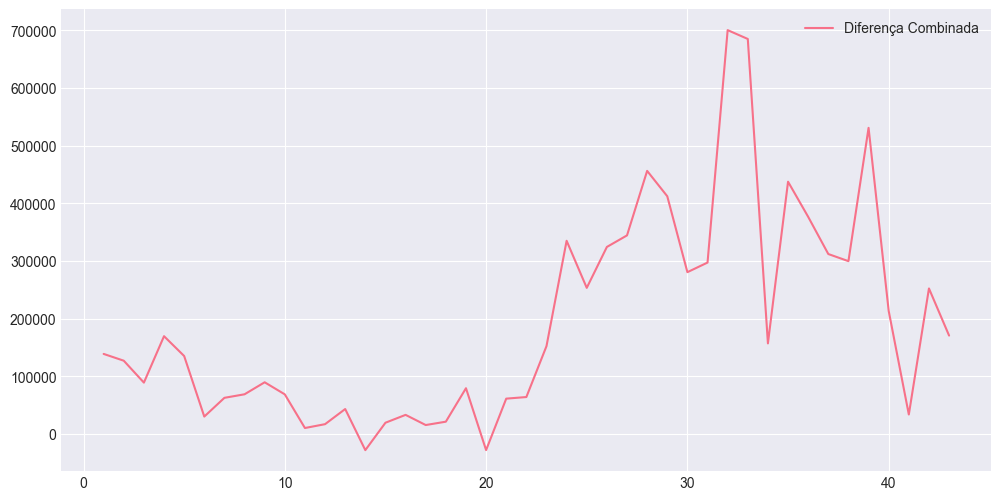

P-value após diff combinada: 0.67027742991181


In [14]:
df = pd.read_csv('../09_Matriculas_BR.csv')
# Aplicando diffs para estacionaridade no df

# Plotando para visualizar o efeito
plt.figure(figsize=(12, 6))
plt.plot(df['value'])
plt.legend()
plt.show()

# Primeiro remove a sazonalidade, depois a tendência do resultado
# Equivalente a D=1 e d=1 no SARIMA
df['diff_combinada'] = df['value'].diff(1)

plt.figure(figsize=(12, 6))
plt.plot(df['diff_combinada'], label='Diferença Combinada')
plt.legend()
plt.show()

# Verificação final com ADF
resultado_final = adfuller(df['diff_combinada'].dropna())
print(f'P-value após diff combinada: {resultado_final[1]}')

AVISO: Série contém valores negativos

📊 DADOS FALTANTES DETECTADOS
Quantidade: 6 (12.24%)
Método de interpolação: linear
✓ Interpolação concluída

SÉRIE TEMPORAL: diff_combinada
Período: 1970-01-01 00:00:00 até 2018-01-01 00:00:00
Frequência: YS
Total de observações: 49
Treino: 39 | Teste: 10


INICIANDO ANÁLISE COMPLETA DE SÉRIE TEMPORAL

1. ANÁLISE EXPLORATÓRIA DE DADOS

ESTATÍSTICAS DESCRITIVAS
--------------------------------------------------
Média...................................       190119.90
Mediana.................................       138757.00
Desvio Padrão...........................       182400.98
Coef. Variação..........................           95.94
Mínimo..................................       -28206.00
Máximo..................................       700580.00
Amplitude...............................       728786.00
Q1 (25%)................................        43110.00
Q3 (75%)................................       299707.00
IQR...............................

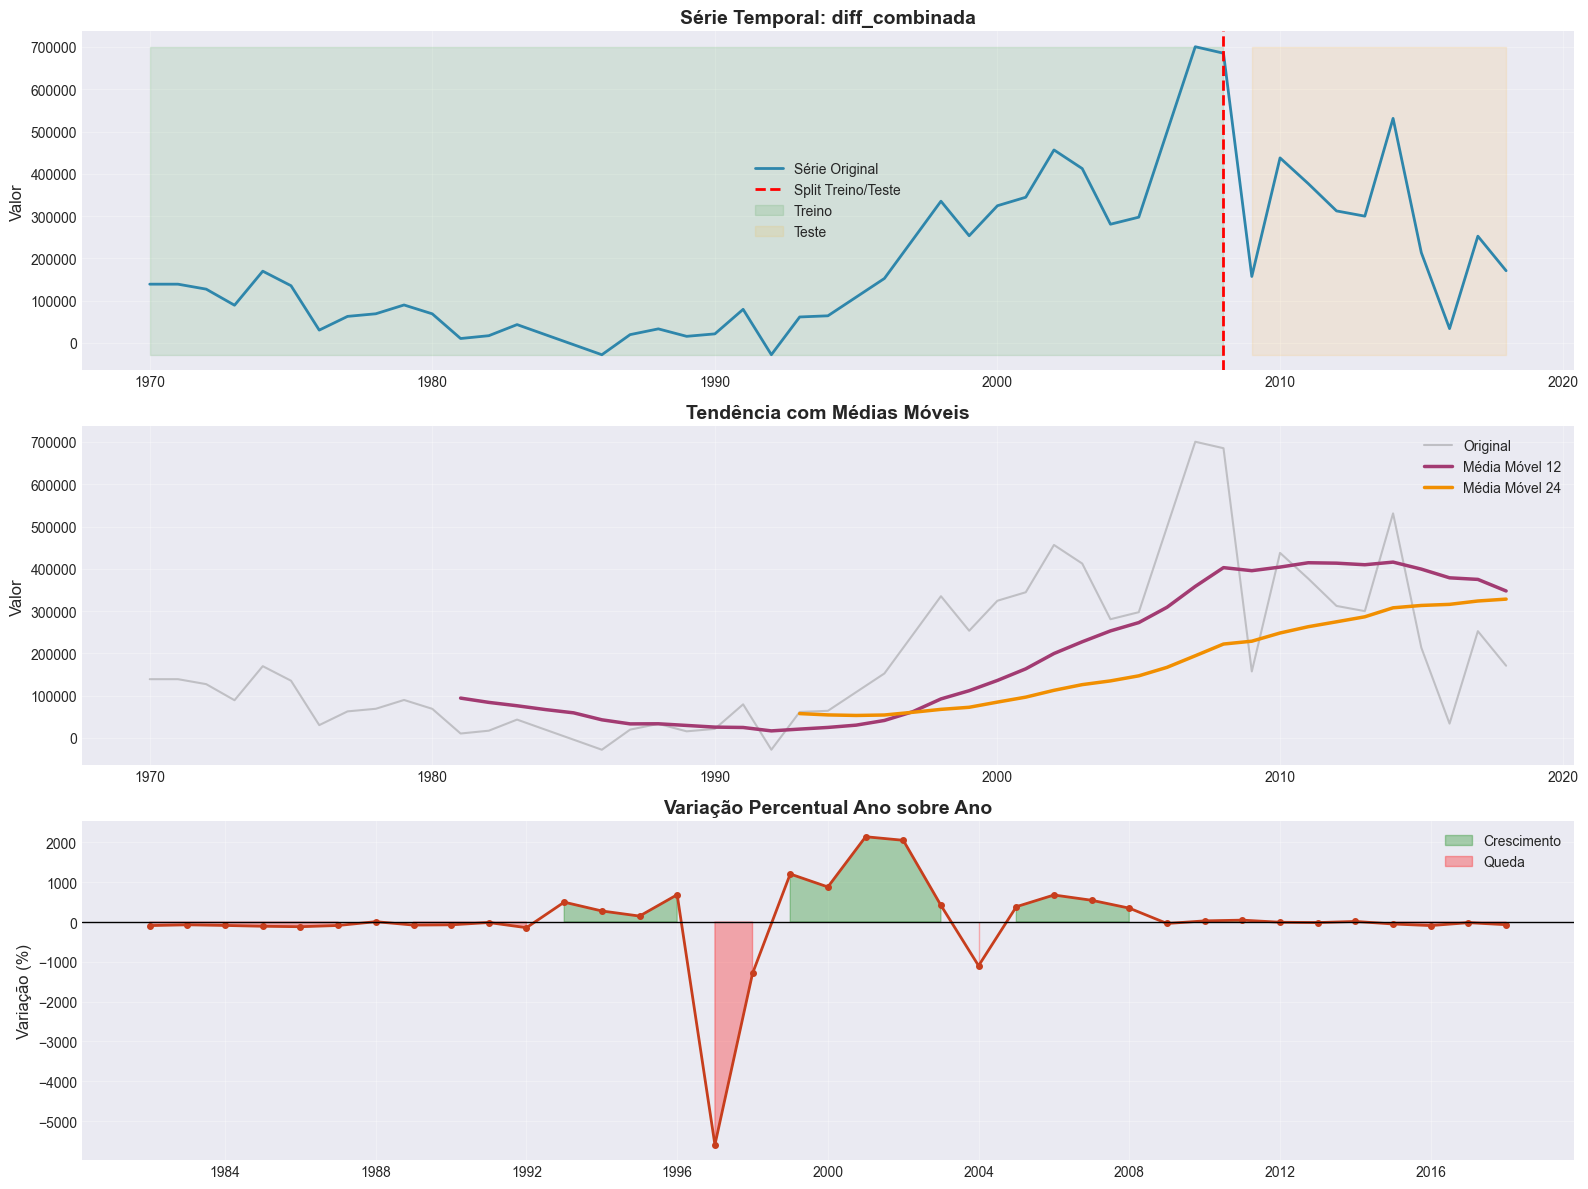

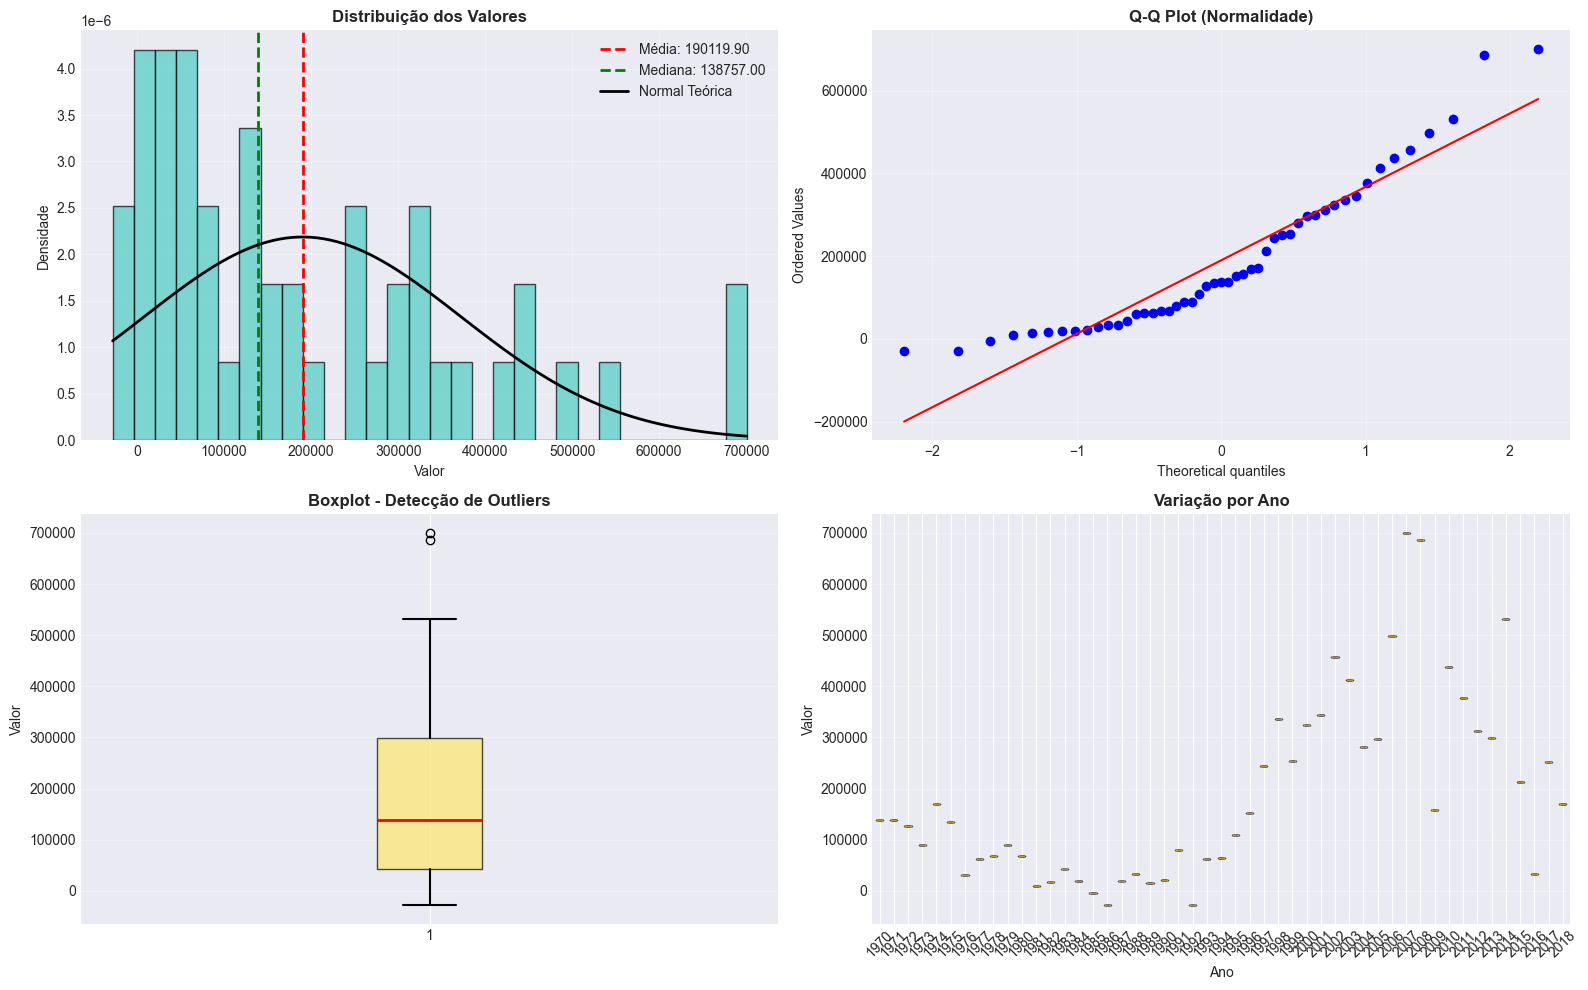

TESTE DE NORMALIDADE (Jarque-Bera)
Estatística: 9.3413
P-valor: 0.0094
Conclusão: Distribuição NÃO-NORMAL (α=0.05)

DETECÇÃO DE OUTLIERS
Método IQR: 2 outliers (4.08%)
Método Z-Score (>3): 0 outliers (0.00%)

Outliers detectados (IQR):
  2007-01-01: 700580.00
  2008-01-01: 685258.00



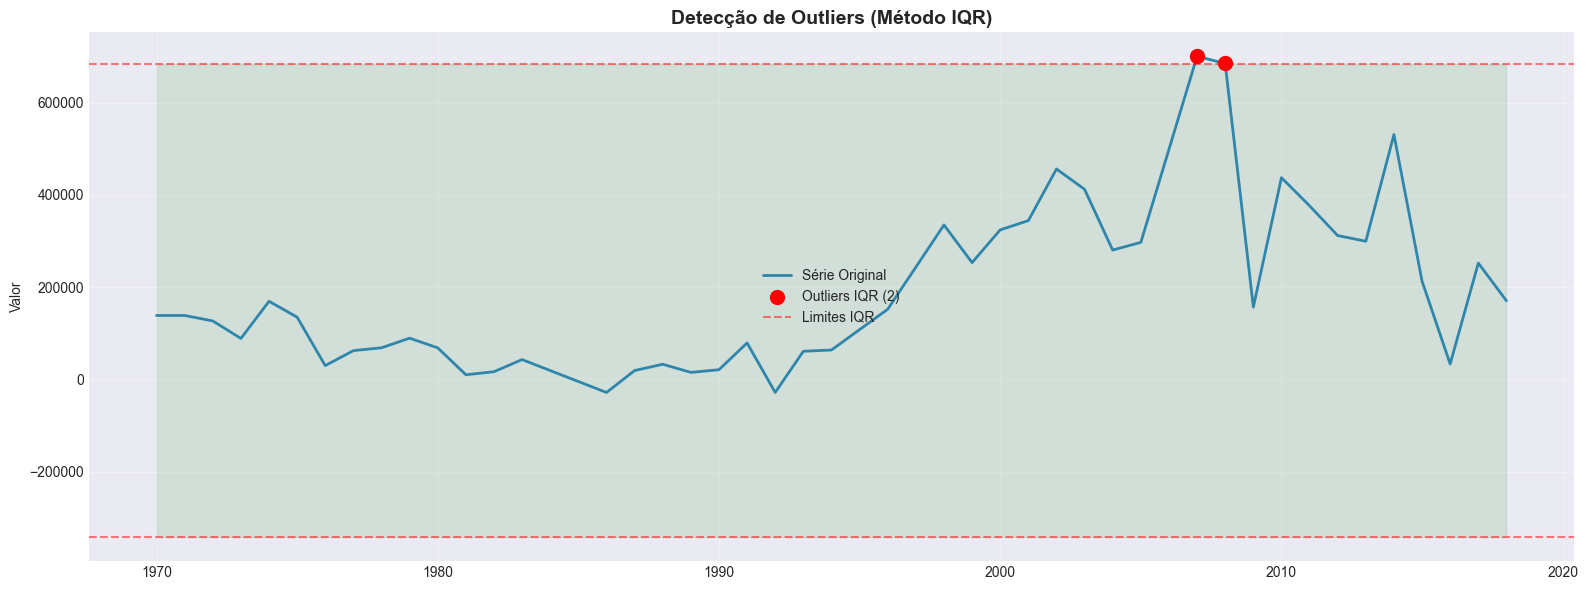


2. DECOMPOSIÇÃO SAZONAL

Não foi possível realizar decomposição clássica: Multiplicative seasonality is not appropriate for zero and negative values

Não foi possível realizar decomposição STL: period must be a positive integer >= 2


3. TESTES DE ESTACIONARIEDADE

TESTE ADF (Augmented Dickey-Fuller)
--------------------------------------------------
Estatística ADF: 1.700820
P-valor: 0.998131
Lags utilizados: 3
Número de observações: 35
Valores críticos:
  1%: -3.6327
  5%: -2.9485
  10%: -2.6130
Conclusão: Série é NÃO-ESTACIONÁRIA (não rejeita H0)

TESTE KPSS (Kwiatkowski-Phillips-Schmidt-Shin)
--------------------------------------------------
Estatística KPSS: 0.270355
P-valor: 0.010000
Lags utilizados: 3
Valores críticos:
  10%: 0.1190
  5%: 0.1460
  2.5%: 0.1760
  1%: 0.2160
Conclusão: Série é NÃO-ESTACIONÁRIA (rejeita H0)

INTERPRETAÇÃO COMBINADA:
Série é NÃO-ESTACIONÁRIA (ambos os testes concordam)



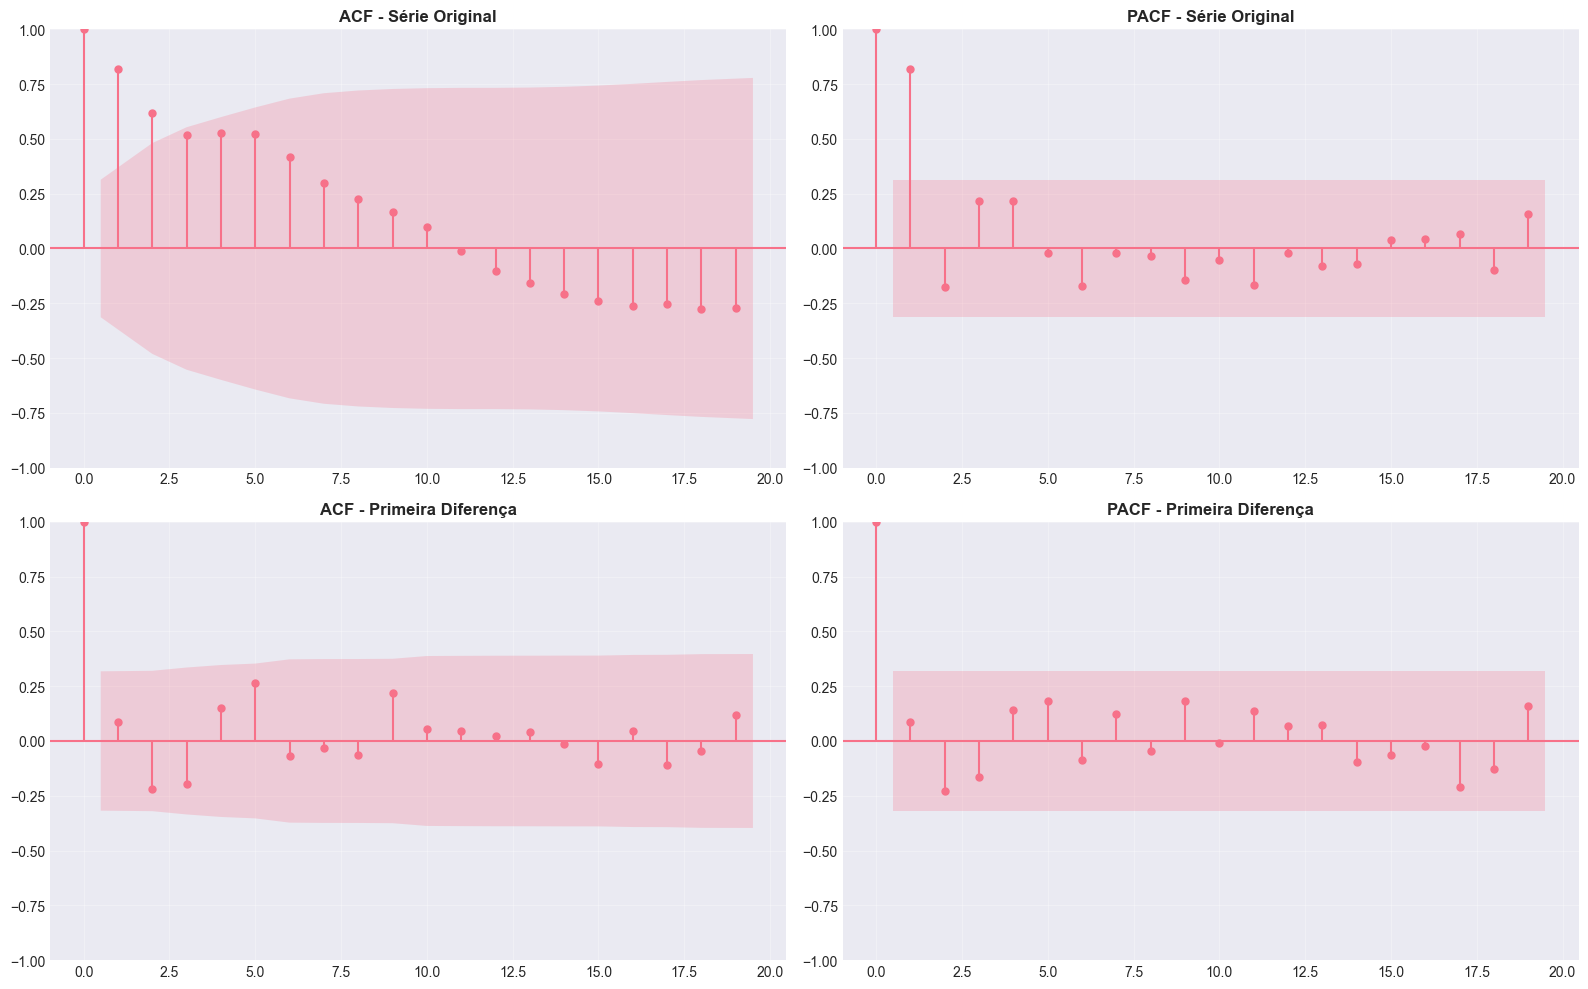


4. AJUSTE E COMPARAÇÃO DE MODELOS

RANDOM FOREST REGRESSOR
--------------------------------------------------
Random Forest treinado com sucesso
  Número de árvores: 200
  Features mais importantes:
    rolling_mean_3: 0.1101
    lag_2: 0.1029
    ano: 0.0921
    rolling_std_12: 0.0872
    rolling_std_6: 0.0852


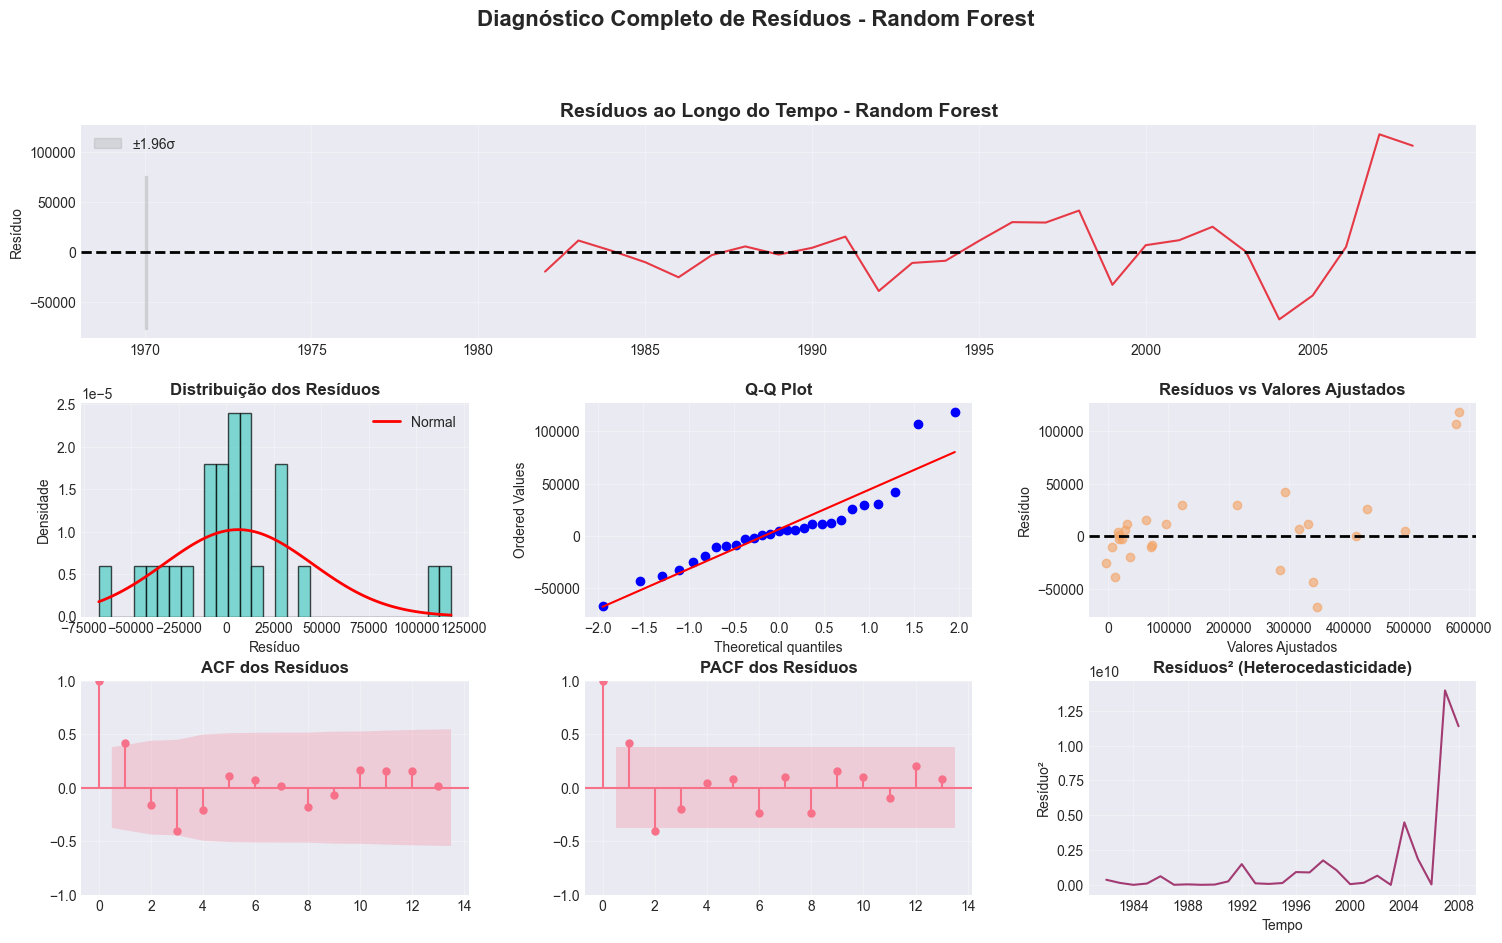


TESTES ESTATÍSTICOS DOS RESÍDUOS - Random Forest
------------------------------------------------------------
Teste Jarque-Bera (Normalidade):
  Estatística: 11.8772 | P-valor: 0.0026
  ✗ Resíduos NÃO-NORMAIS

Teste Ljung-Box (Autocorrelação):
  P-valor mínimo: 0.0096
  ✗ COM autocorrelação

Estatísticas dos Resíduos:
  Média: 6345.249613 (deveria ser ~0)
  Desvio Padrão: 38959.0076
  Assimetria: 1.2400
  Curtose: 2.9951
------------------------------------------------------------

Random Forest ajustado com sucesso

HOLT-WINTERS (SUAVIZAÇÃO EXPONENCIAL)
--------------------------------------------------
✓ Melhor configuração: HW_add_add
  AIC: 888.09
  BIC: 906.39


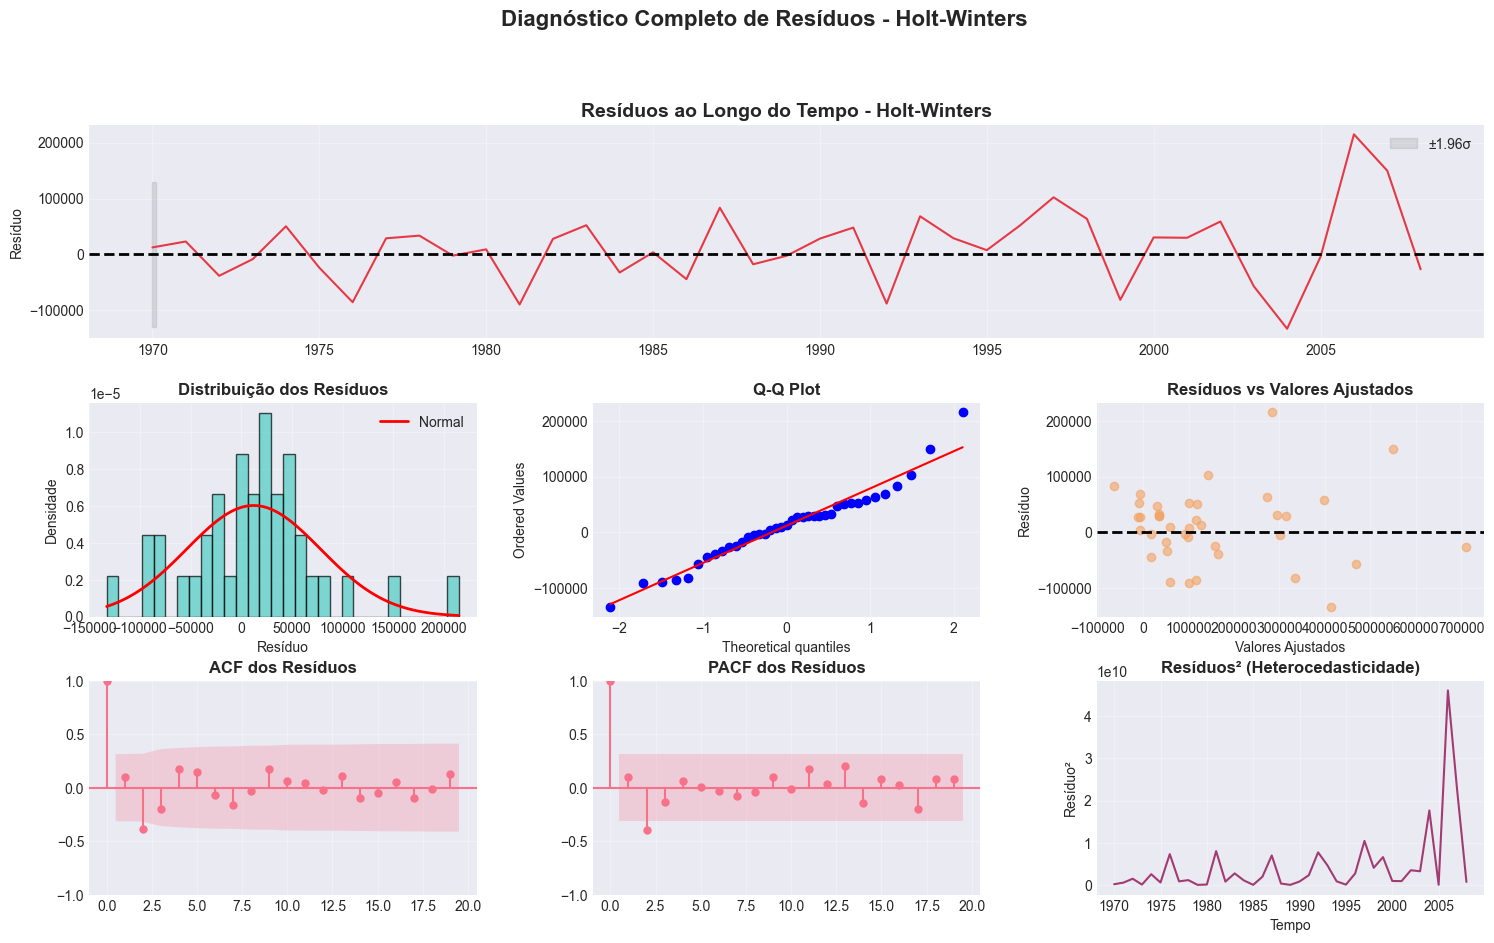


TESTES ESTATÍSTICOS DOS RESÍDUOS - Holt-Winters
------------------------------------------------------------
Teste Jarque-Bera (Normalidade):
  Estatística: 4.0040 | P-valor: 0.1351
  Resíduos NORMAIS

Teste Ljung-Box (Autocorrelação):
  P-valor mínimo: 0.0331
  ✗ COM autocorrelação

Estatísticas dos Resíduos:
  Média: 12166.718904 (deveria ser ~0)
  Desvio Padrão: 66151.4316
  Assimetria: 0.4773
  Curtose: 1.6247
------------------------------------------------------------

✓ Holt-Winters ajustado com sucesso

SARIMA (AUTO-ARIMA)
--------------------------------------------------
Buscando melhor modelo SARIMA (pode levar alguns minutos)...
Melhor modelo: ARIMA(0, 2, 1) x (0, 0, 0, 0)[1]
  AIC: 940.29
  BIC: 943.51


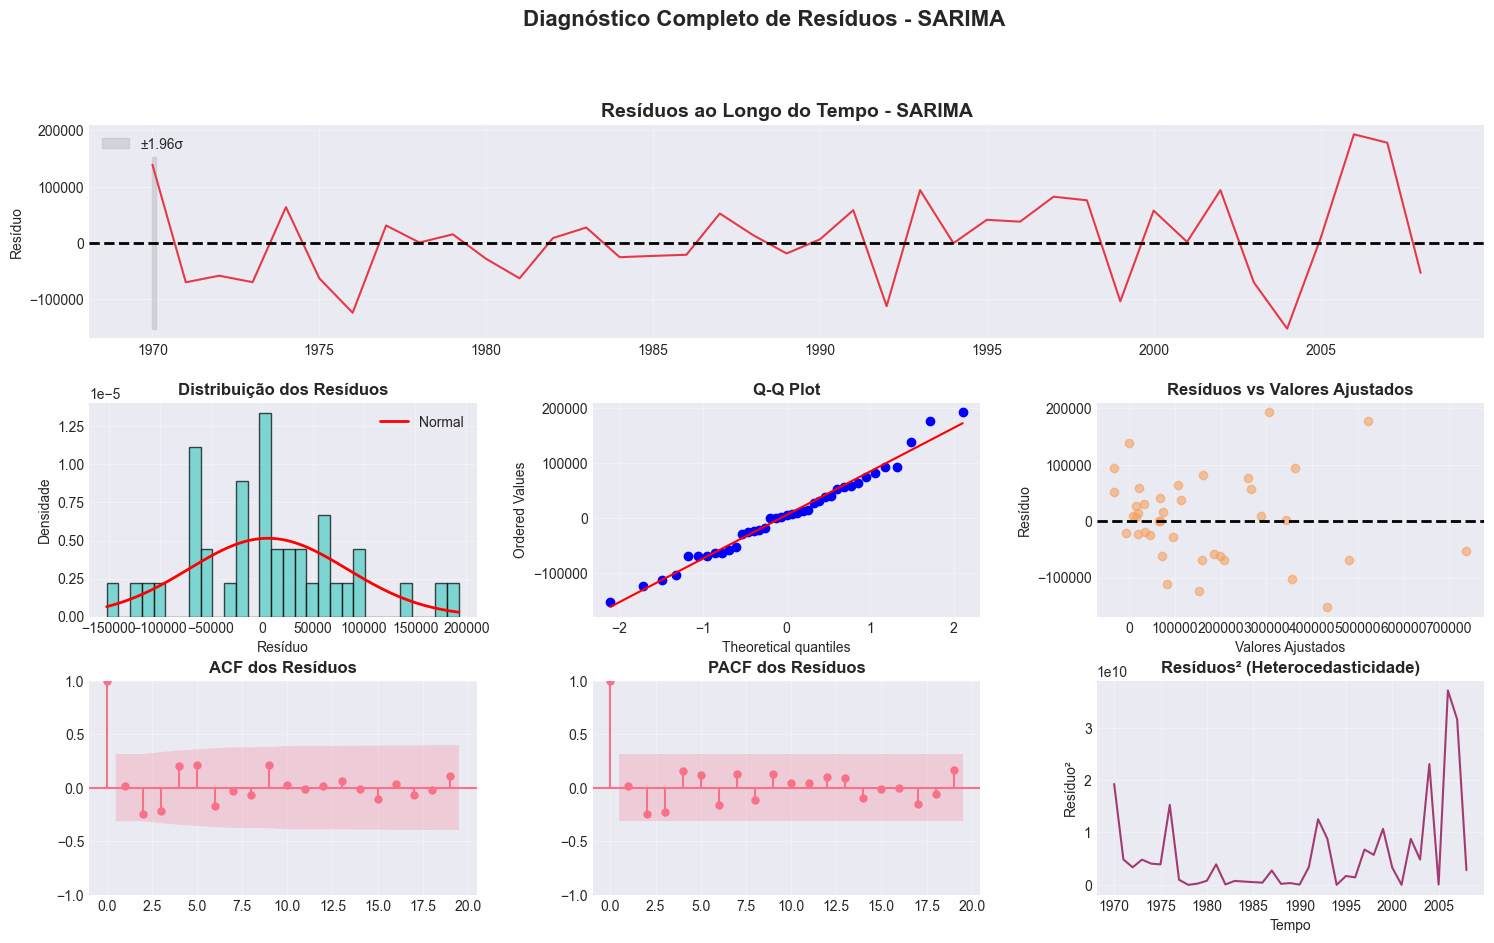


TESTES ESTATÍSTICOS DOS RESÍDUOS - SARIMA
------------------------------------------------------------
Teste Jarque-Bera (Normalidade):
  Estatística: 0.5810 | P-valor: 0.7479
  Resíduos NORMAIS

Teste Ljung-Box (Autocorrelação):
  P-valor mínimo: 0.1209
  SEM autocorrelação (Ruído Branco)

Estatísticas dos Resíduos:
  Média: 5860.714519 (deveria ser ~0)
  Desvio Padrão: 77520.7946
  Assimetria: 0.3110
  Curtose: 0.1788
------------------------------------------------------------

SARIMA ajustado com sucesso

PROPHET
--------------------------------------------------
Erro no Prophet: Length mismatch: Expected axis has 3 elements, new values have 2 elements


5. COMPARAÇÃO VISUAL DOS MODELOS



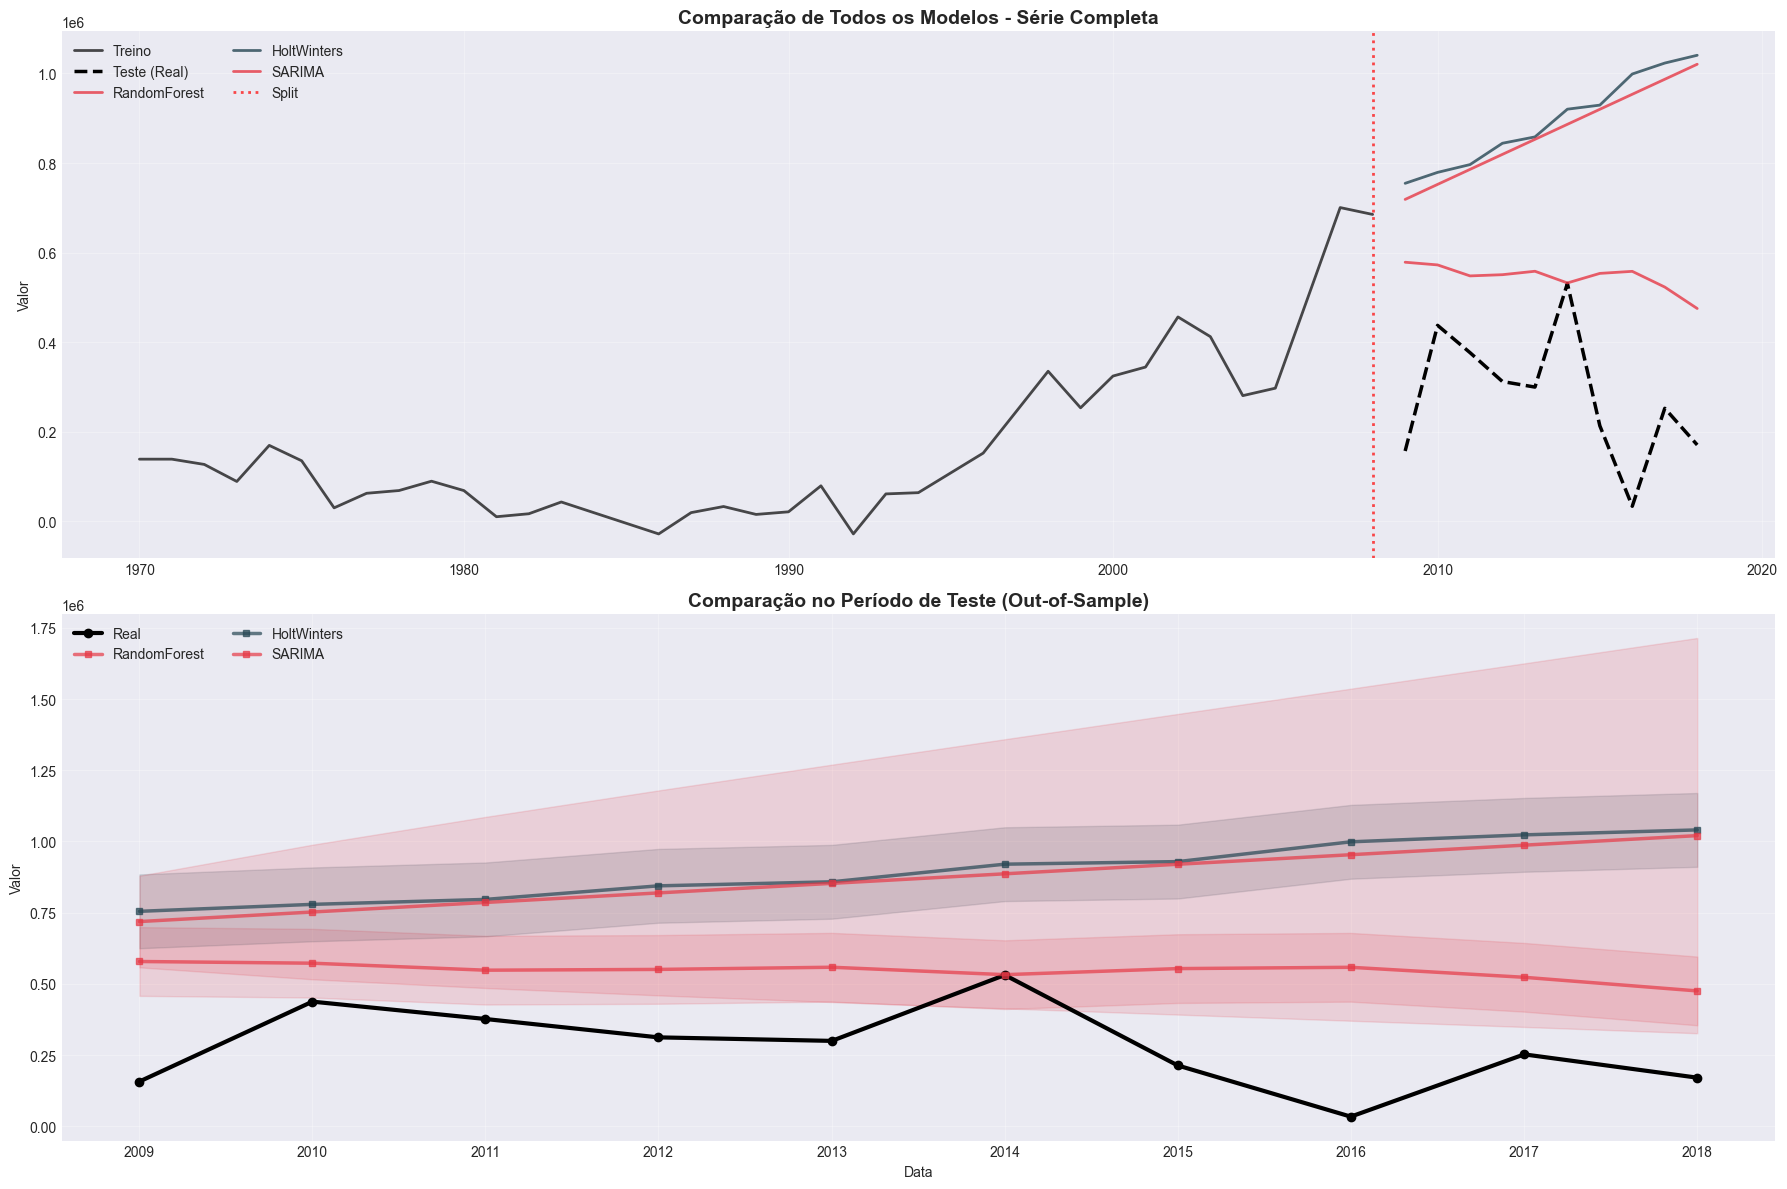


6. RANKING E MÉTRICAS DE PERFORMANCE

TABELA DE MÉTRICAS (ordenada por melhor performance)
                      MAE         RMSE      MAPE     SMAPE       R²  Rank_Médio
RandomForest  266660.9861  301027.4715  251.3793   72.4442  -3.7297         1.0
SARIMA        591340.9591  622923.0043  481.0211  105.9812 -19.2532         2.0
HoltWinters   616182.0384  647544.2782  502.3350  107.7885 -20.8858         3.0

MELHOR MODELO: RandomForest
   MAE: 266660.9861
   RMSE: 301027.4715
   MAPE: 251.38%
   R²: -3.7297


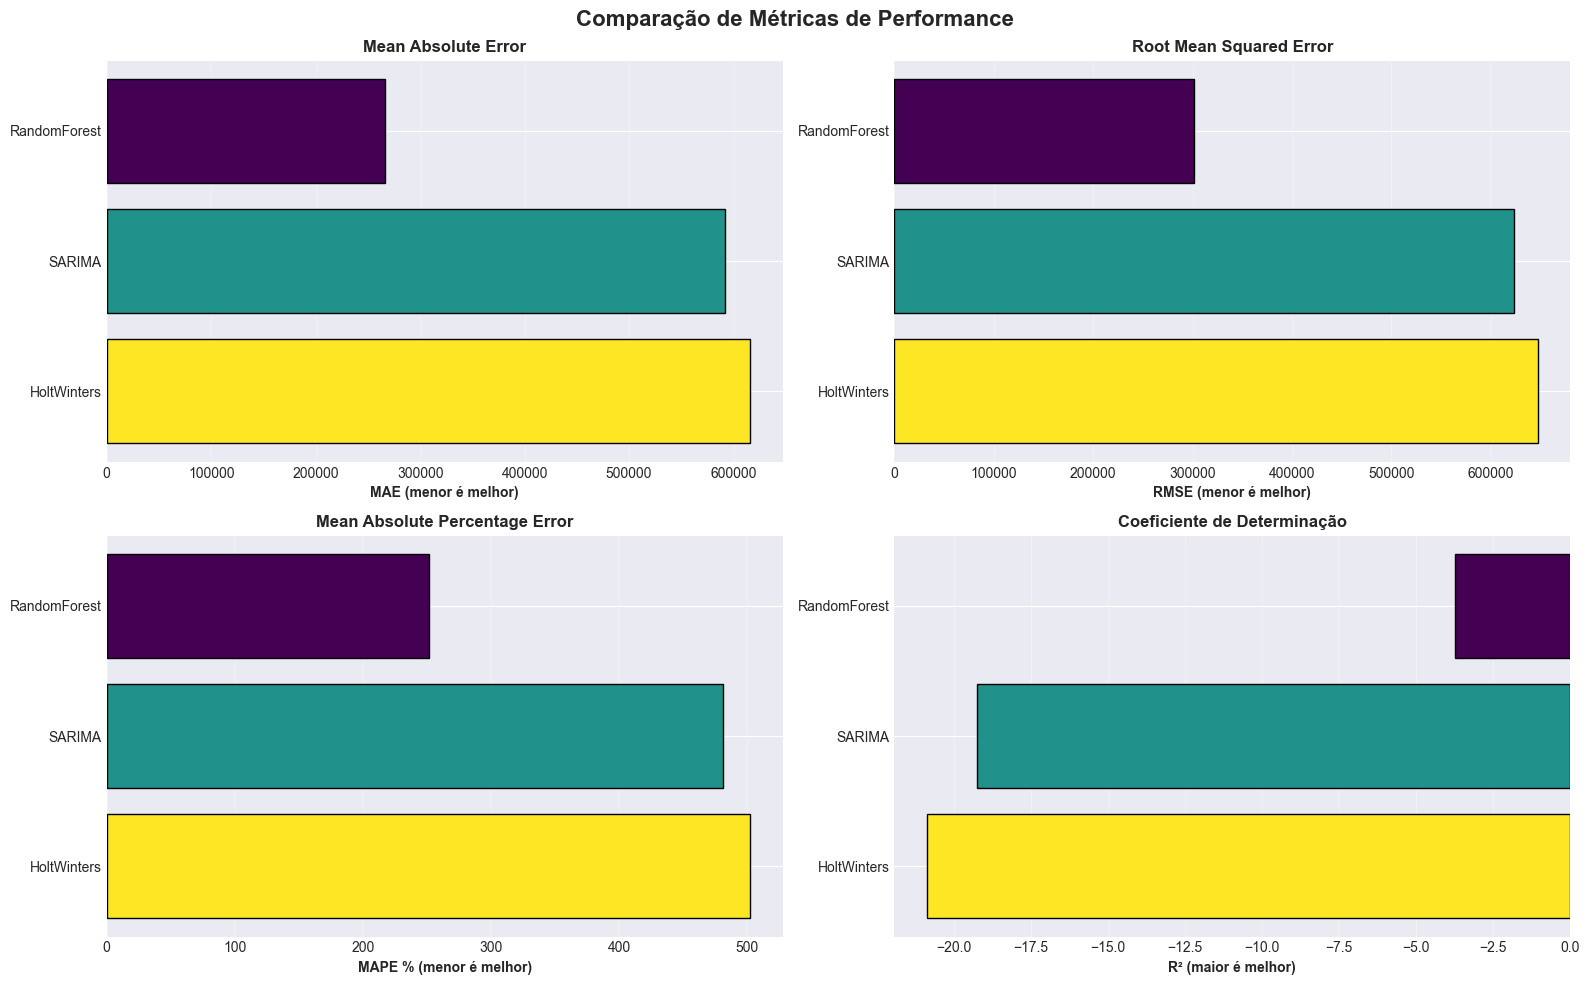


PREVISÃO FUTURA - 12 PERÍODOS À FRENTE

Gerando previsões com Random Forest...
✓ Random Forest concluído
Gerando previsões com Holt-Winters...
✓ Holt-Winters concluído
Gerando previsões com SARIMA...
✓ SARIMA concluído


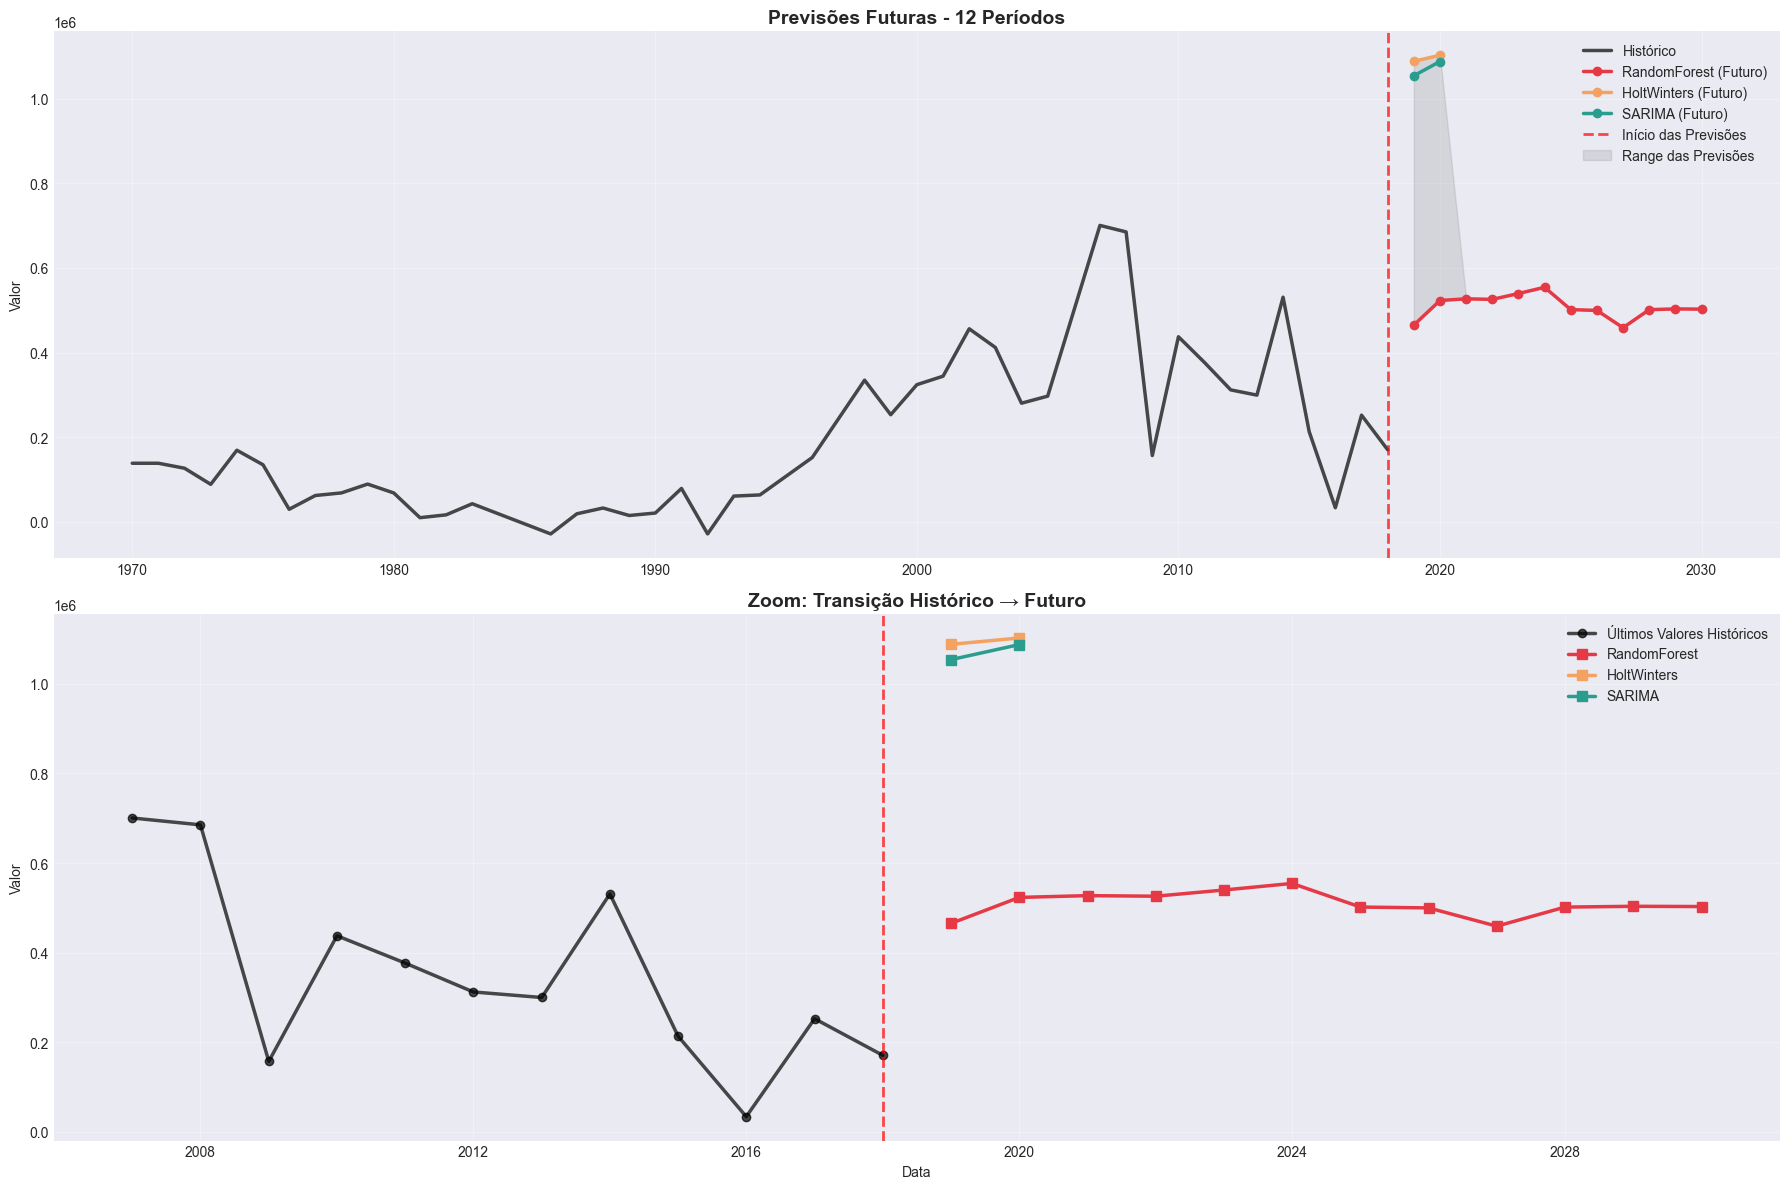


RESUMO DAS PREVISÕES FUTURAS

            RandomForest  HoltWinters      SARIMA
2019-01-01     465143.36   1088352.55  1054196.12
2020-01-01     523192.59   1102537.19  1087735.95
2021-01-01     527176.51          NaN         NaN
2022-01-01     525891.65          NaN         NaN
2023-01-01     539712.46          NaN         NaN
2024-01-01     554419.50          NaN         NaN
2025-01-01     501696.68          NaN         NaN
2026-01-01     499768.64          NaN         NaN
2027-01-01     458958.21          NaN         NaN
2028-01-01     501559.87          NaN         NaN
2029-01-01     503364.09          NaN         NaN
2030-01-01     502802.50          NaN         NaN

Estatísticas por período:
       RandomForest  HoltWinters      SARIMA
count         12.00         2.00        2.00
mean      508640.50   1095444.87  1070966.03
std        27819.95     10030.05    23716.24
min       458958.21   1088352.55  1054196.12
25%       501112.07   1091898.71  1062581.08
50%       503083.30   

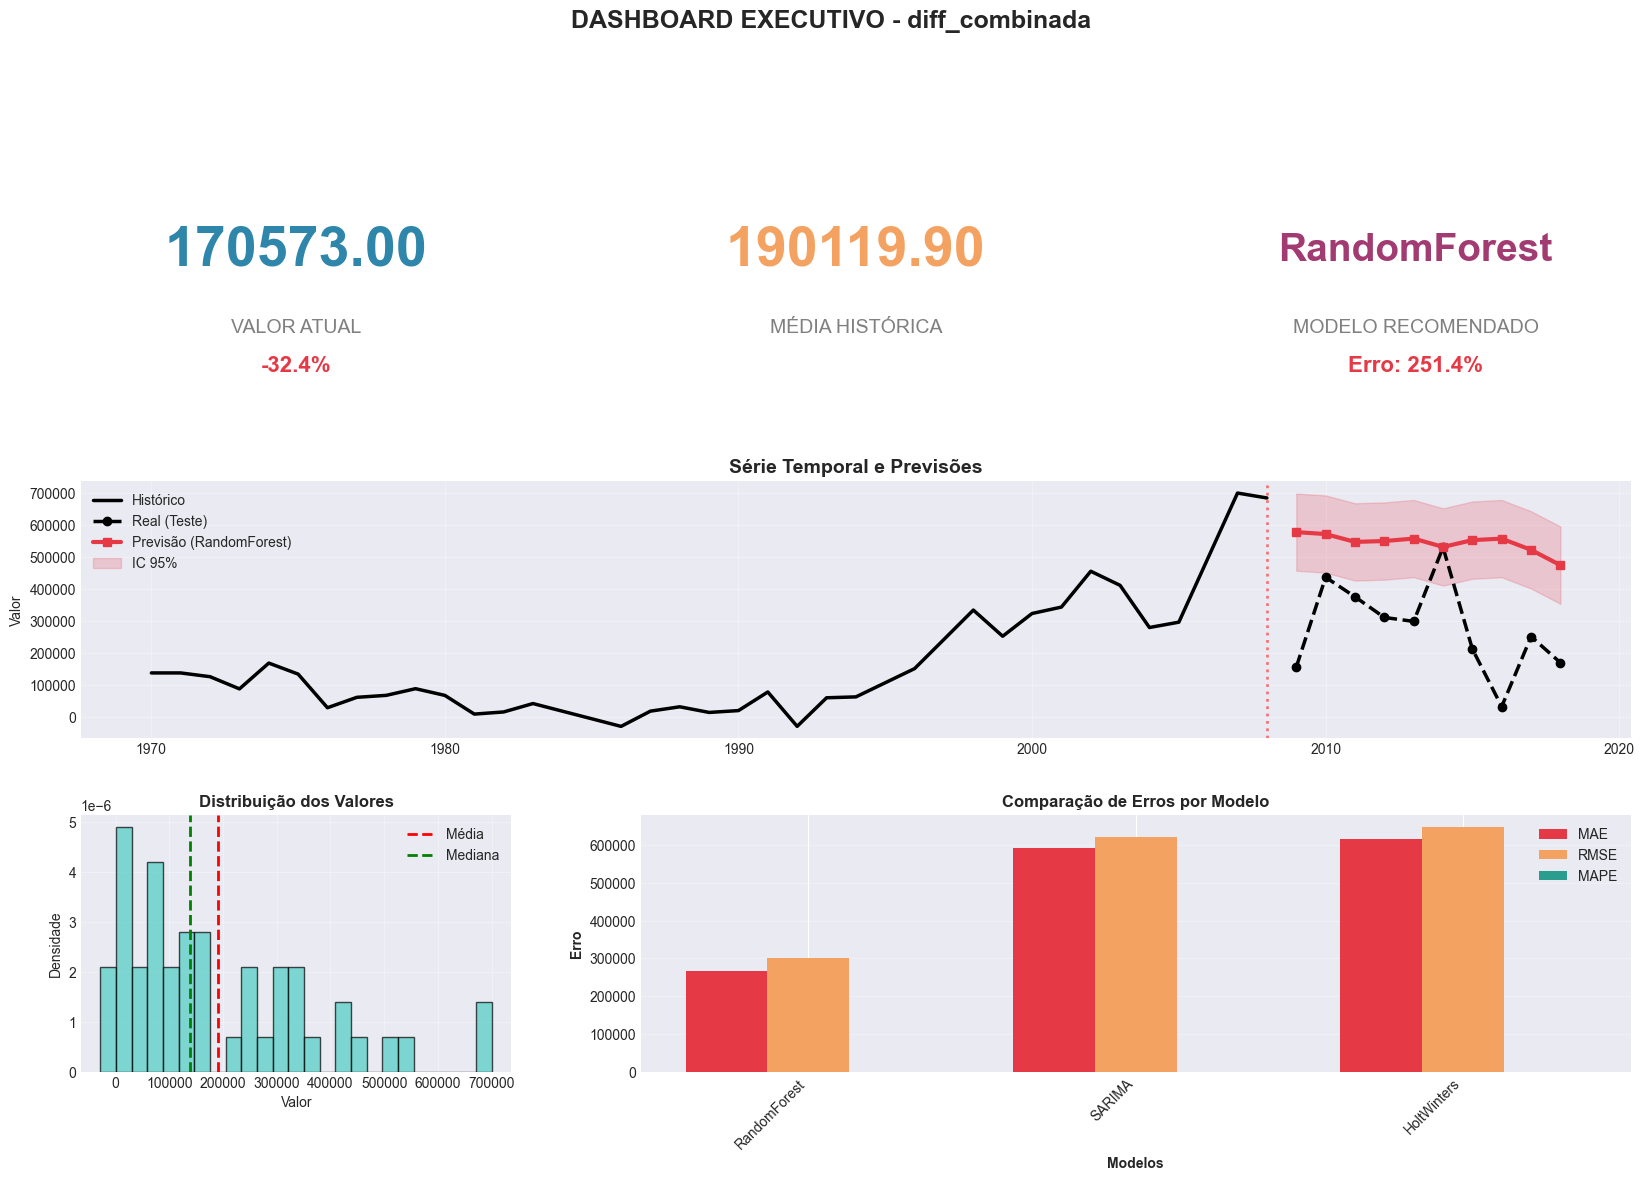


7. RELATÓRIO EXECUTIVO

RESUMO DA ANÁLISE
--------------------------------------------------------------------------------
Variável Analisada: diff_combinada
Período: 1970-01-01 até 2018-01-01
Total de Observações: 49
Frequência: YS

Tendência Geral: CRESCIMENTO de 22.9%
Valor Médio: 190119.90
Volatilidade (CV): 95.9%

🏆 MODELO RECOMENDADO: RandomForest
   Precisão: -151.4% (Erro médio: 251.4%)
   Interpretação: O modelo erra em média 251.4% do valor real

PRÓXIMA PREVISÃO: 578530.00
   Intervalo de Confiança 95%: [457866.48, 699193.52]
   Cenário Pessimista: 457866.48
   Cenário Mais Provável: 578530.00
   Cenário Otimista: 699193.52

ANÁLISE COMPLETA FINALIZADA



In [15]:
analisador = AnalisadorSerieTemporalCompleto(
    df=df,
    data_col='date',
    valor_col='diff_combinada',
    frequencia='YS', 
    test_size=0.2
)
previsoes = analisador.analise_completa(periodos_futuros=12)